# 06 — Evaluación del modelo en producción

Este notebook **no entrena nada**. Carga los artefactos que hay en `models/` y comprueba que
reproducen las métricas documentadas en [`docs/modelo-ml.md`](../docs/modelo-ml.md).

Usa la misma clase `RedDerrocheV2` que emplean la app y el pipeline en tiempo real
(`src/derroche/`), de modo que si el `.pt` guardado y el código de inferencia se
desincronizan, este notebook falla en vez de dar métricas engañosas.

Genera además las figuras `docs/img/10_matriz_confusion.png` y
`docs/img/12_curva_precision_recall.png`.

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score,
)

ROOT = Path("..").resolve()
IMG = ROOT / "docs" / "img"
from derroche import build_frame, cargar_bundle, FEATURE_COLS
from derroche.modelo import RedDerrocheV2   # misma clase que usan la app y el pipeline live

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

## 1. Dataset y features

Se reconstruyen las 31 features exactamente igual que en `05_red_neuronal_v2.ipynb`:
lags de 1-3 h, deltas de temperatura, codificación cíclica del calendario e interacciones.

In [2]:
df = pd.read_csv(ROOT / "data/gold/dataset_entrenamiento.csv", index_col=0, parse_dates=True).sort_index()

# Mismo `build_frame` que usa el notebook de entrenamiento y, via `build_vector`,
# la app y el servicio en tiempo real. Una sola definicion de las features.
df = build_frame(df).dropna()
print(f"Muestras: {len(df)}")

Muestras: 3921


## 2. Artefactos guardados

`feature_cols` y `best_threshold` salen del propio checkpoint: el orden de las columnas y el
umbral no se reescriben aquí, se leen de lo que se guardó al entrenar.

In [3]:
ckpt = torch.load(ROOT / "models/model_derroche_v2.pt", map_location="cpu", weights_only=False)
scaler = joblib.load(ROOT / "models/scaler_derroche_v2.joblib")

THRESHOLD = ckpt["best_threshold"]

# El checkpoint guarda su propia lista de features. Si no coincide con la del
# paquete, el modelo guardado y el codigo que sirve han divergido.
assert list(ckpt["feature_cols"]) == FEATURE_COLS, "el checkpoint no coincide con derroche.FEATURE_COLS"

print(f"Features: {ckpt['input_dim']}  |  hidden_dim: {ckpt['hidden_dim']}  |  umbral: {THRESHOLD:.2f}")
print("El orden de features del checkpoint coincide con el del paquete.")

X = scaler.transform(df[FEATURE_COLS].values.astype(np.float32))
y = df["derroche_siguiente_hora"].values.astype(np.int64)

Features: 31  |  hidden_dim: 128  |  umbral: 0.50
El orden de features del checkpoint coincide con el del paquete.


## 3. Partición temporal

Misma partición que en el entrenamiento: 70 % / 15 % / 15 % **sin shuffle**, para no filtrar
información del futuro hacia el pasado.

In [4]:
idx = np.arange(len(X))
idx_train, idx_temp = train_test_split(idx, test_size=0.3, shuffle=False)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.5, shuffle=False)

X_test, y_test = X[idx_test], y[idx_test]
print(f"Train: {len(idx_train)}, Val: {len(idx_val)}, Test: {len(X_test)}")
print(f"Derroche en test: {y_test.sum()} ({y_test.mean():.2%})")

Train: 2744, Val: 588, Test: 589
Derroche en test: 158 (26.83%)


## 4. Inferencia

Si el checkpoint no encaja con la clase de `derroche.modelo`, `load_state_dict` lanza aquí.

In [5]:
model = RedDerrocheV2(ckpt["input_dim"], ckpt["hidden_dim"])
model.load_state_dict(ckpt["model_state"])
model.eval()

with torch.no_grad():
    prob = torch.sigmoid(model(torch.tensor(X_test, dtype=torch.float32))).numpy().ravel()
pred = (prob >= THRESHOLD).astype(int)

## 5. Métricas

Se comparan con los valores de `docs/modelo-ml.md`. Cualquier desviación significa que el
artefacto de `models/` no corresponde al run documentado.

In [6]:
ESPERADO = {"Accuracy": 0.9083, "Precision": 0.7889, "Recall": 0.8987,
            "F1-Score": 0.8402, "ROC-AUC": 0.9660}
obtenido = {
    "Accuracy":  accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred, zero_division=0),
    "Recall":    recall_score(y_test, pred, zero_division=0),
    "F1-Score":  f1_score(y_test, pred, zero_division=0),
    "ROC-AUC":   roc_auc_score(y_test, prob),
}

print(f"{'Métrica':<11}{'Obtenido':>10}{'Docs':>10}{'Δ':>10}")
for k, v in obtenido.items():
    print(f"{k:<11}{v:>10.4f}{ESPERADO[k]:>10.4f}{v - ESPERADO[k]:>+10.4f}")

desviadas = [k for k, v in obtenido.items() if abs(v - ESPERADO[k]) > 0.005]
print("\n" + ("OK: el modelo guardado reproduce las métricas documentadas."
               if not desviadas else
               f"AVISO: desviación en {desviadas}. Revisa si models/ y docs/ están sincronizados."))

Métrica      Obtenido      Docs         Δ
Accuracy       0.9083    0.9083   +0.0000
Precision      0.7889    0.7889   -0.0000
Recall         0.8987    0.8987   +0.0000
F1-Score       0.8402    0.8402   +0.0000
ROC-AUC        0.9660    0.9660   -0.0000

OK: el modelo guardado reproduce las métricas documentadas.


In [7]:
print(classification_report(y_test, pred, target_names=["No derroche", "Derroche"], zero_division=0))

              precision    recall  f1-score   support

 No derroche       0.96      0.91      0.94       431
    Derroche       0.79      0.90      0.84       158

    accuracy                           0.91       589
   macro avg       0.87      0.91      0.89       589
weighted avg       0.91      0.91      0.91       589



## 6. Matriz de confusión

El coste asimétrico del problema se lee en la esquina inferior izquierda: los falsos negativos
son derroches reales que el sistema no detecta.

[[393  38]
 [ 16 142]]


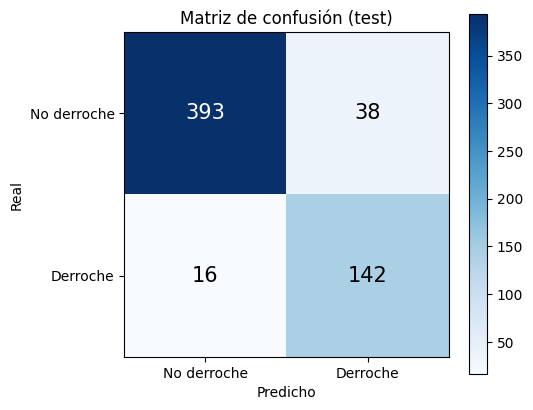

In [8]:
cm = confusion_matrix(y_test, pred)
print(cm)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], labels=["No derroche", "Derroche"])
ax.set_yticks([0, 1], labels=["No derroche", "Derroche"])
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión (test)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=15,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im)
plt.tight_layout()
plt.savefig(IMG / "10_matriz_confusion.png", dpi=110)
plt.show()

## 7. Curva Precision-Recall

Más informativa que la ROC con clases desbalanceadas (27 % de positivos): la línea base de un
clasificador aleatorio es la proporción de positivos, no 0.5.

Average precision: 0.9005  (línea base aleatoria: 0.2683)


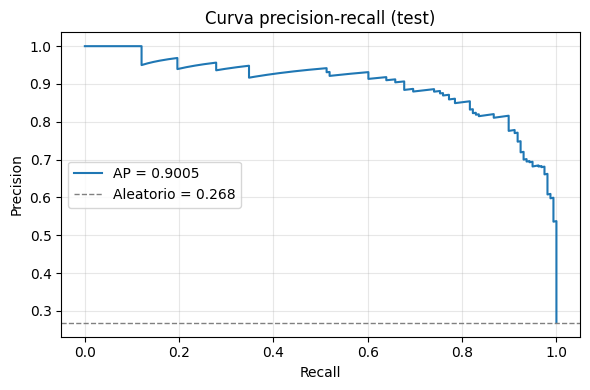

In [9]:
precision_c, recall_c, _ = precision_recall_curve(y_test, prob)
ap = average_precision_score(y_test, prob)
print(f"Average precision: {ap:.4f}  (línea base aleatoria: {y_test.mean():.4f})")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(recall_c, precision_c, label=f"AP = {ap:.4f}")
ax.axhline(y_test.mean(), ls="--", color="gray", lw=1, label=f"Aleatorio = {y_test.mean():.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curva precision-recall (test)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG / "12_curva_precision_recall.png", dpi=110)
plt.show()